DATASET LINK FROM KAGGLE("https://www.kaggle.com/code/tanmay111999/heart-failure-prediction-cv-score-90-5-models")

In [ ]:
import numpy as np
import pandas as pd


# LOADING THE DATASET


In [ ]:
f=r'C:\Users\miran\Downloads\MACHINE-LEARNING-FEB-2025-main\MACHINE-LEARNING-FEB-2025-main\Public Datasets\heart (1).csv'

In [ ]:
df=pd.read_csv(f)

our aim is to predict this person has heart disease  or not

# BUSINESS \DATA UNDERSTANDING

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB



Here/s deatils about Dataset:
1-Age: age of the patient [years]

2-Sex: sex of the patient [M: Male, F: Female]

3-ChestPainType: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]

4-RestingBP: resting blood pressure [mm Hg]

5-Cholesterol: serum cholesterol [mm/dl]

6-FastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]

7-RestingECG: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]

8-MaxHR: maximum heart rate achieved [Numeric value between 60 and 202]

9-ExerciseAngina: exercise-induced angina [Y: Yes, N: No]

10-Oldpeak: oldpeak = ST [Numeric value measured in depression]

11-ST_Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]

12-HeartDisease: output class [1: heart disease, 0: Normal]

In [ ]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


the age mean is 53.5 years that mean that most patient are middle age ,,
the youngest patient is 28 and the oldest patient 77 ,
maximum heart rate average is 136 and range between 60 to 202,
the mean of heartdisease is 0.553*100% =55.3% of the dataset patients has heartdisease

In [ ]:
df.shape

(918, 12)

In [ ]:
df.head(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
df.tail(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


In [ ]:
print(df.columns)

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')


In [ ]:
df.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [ ]:
df['RestingECG'].unique

<bound method Series.unique of 0      Normal
1      Normal
2          ST
3      Normal
4      Normal
        ...  
913    Normal
914    Normal
915    Normal
916       LVH
917    Normal
Name: RestingECG, Length: 918, dtype: object>

In [ ]:
print(df.dtypes)

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object


In [ ]:
df.duplicated().sum()

0

DATA PREPRATION

we have no null in dataset and no duplicated and the datatype is correct so there is no need for data preparation we are ready for visualization

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df = df.copy(deep = True)

df['Sex'] = le.fit_transform(df['Sex'])
df['ChestPainType'] = le.fit_transform(df['ChestPainType'])
df['RestingECG'] = le.fit_transform(df['RestingECG'])
df['ExerciseAngina'] = le.fit_transform(df['ExerciseAngina'])
df['ST_Slope'] = le.fit_transform(df['ST_Slope'])

here we encode we convert every string  to numeric
labelencoder is scikit-learn categorical convert string values into numerical label Initializes a label encoder that will convert categories (like 'M', 'F') into numbers(0,1) le.transform convert them into integer labels...The result replaces the original string column with numbers.

note:Creates a deep copy of the DataFrame so the original df isn't modified

In [ ]:
df.head(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,1,108,1,1.5,1,1
4,54,1,2,150,195,0,1,122,0,0.0,2,0


# DATA VISUALIZATION


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

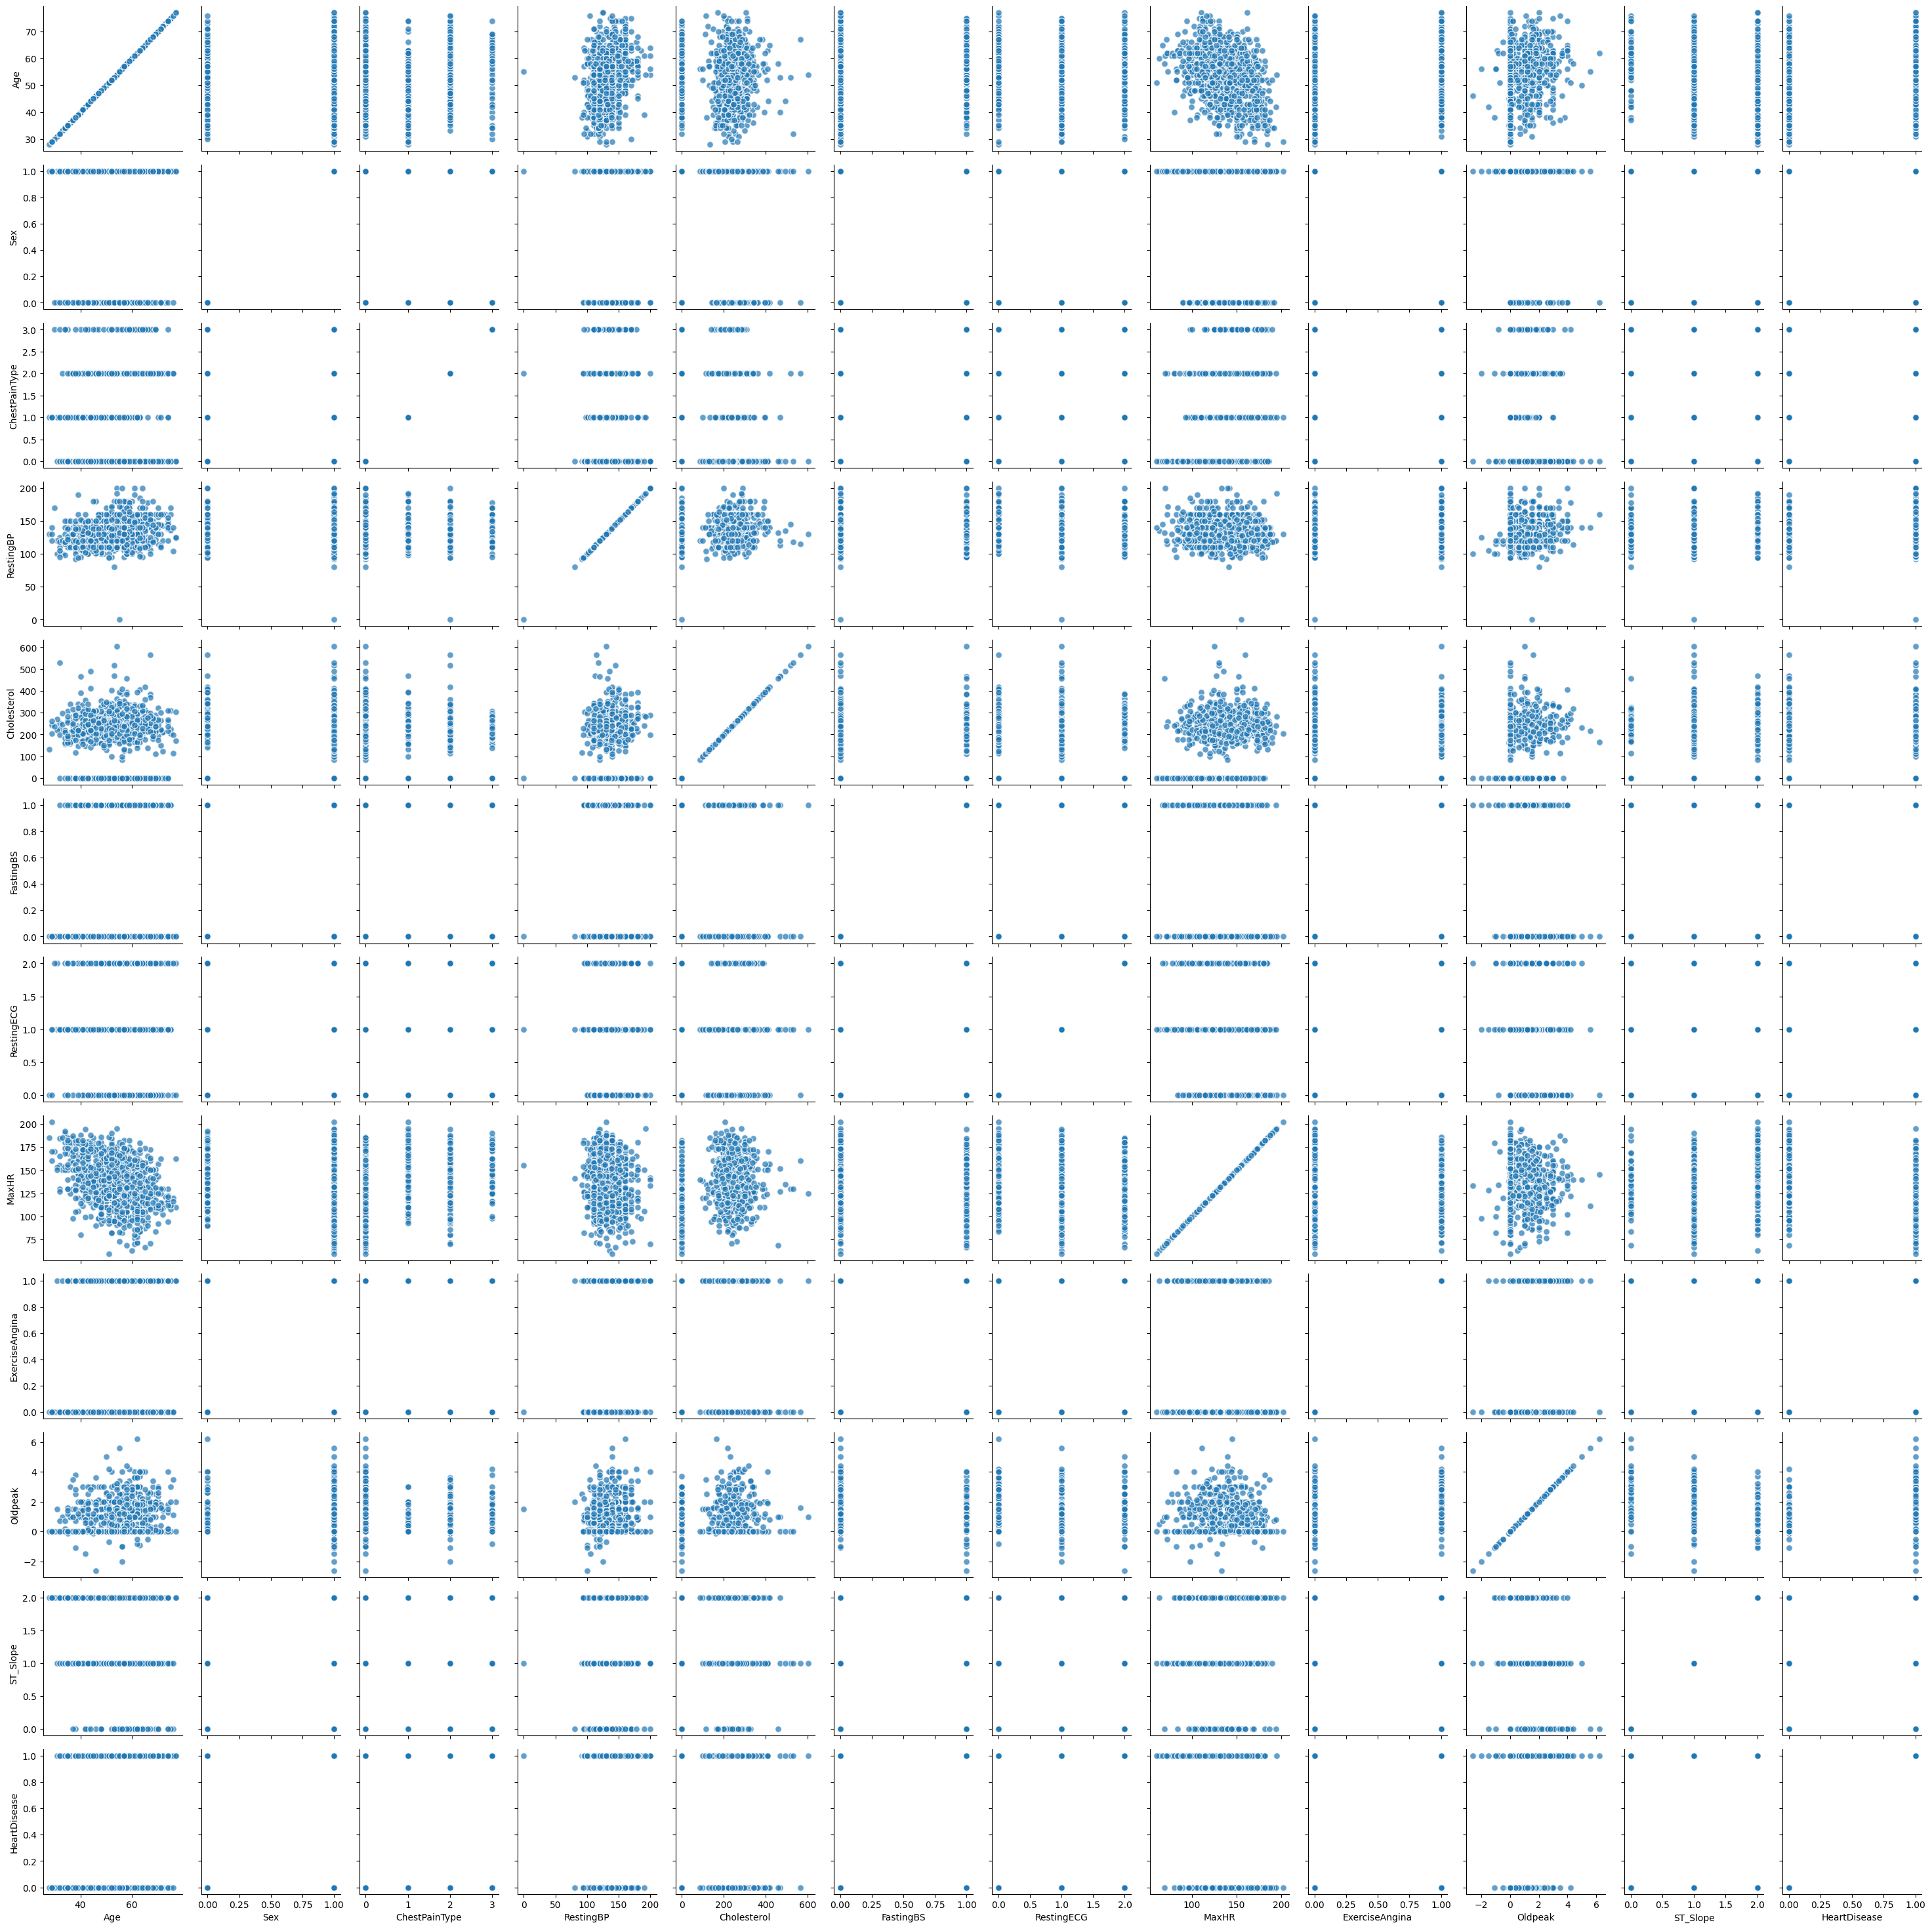

In [ ]:
grid= sns.PairGrid(df)
grid.map(
    func=plt.scatter,
    s=50,
    edgecolor='w',
    alpha=0.7
)

we will find postive and some of same perfect positive correlation and others configure that there is no correction or even week correlation

In [ ]:
dict={1: 'Male', 0: 'Female'}

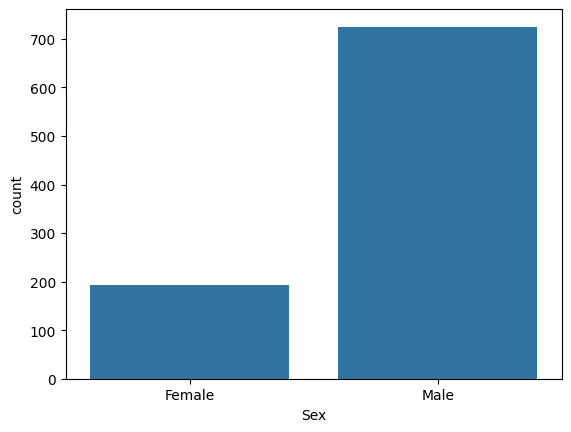

In [ ]:
x=(df.Sex .value_counts())
p = sns.countplot(data=df, x="Sex")
plt.xticks(list(dict.keys()),list(dict.values()))
plt.show()

 Univariate Exploration.
 we configure that M patient is more than the F one

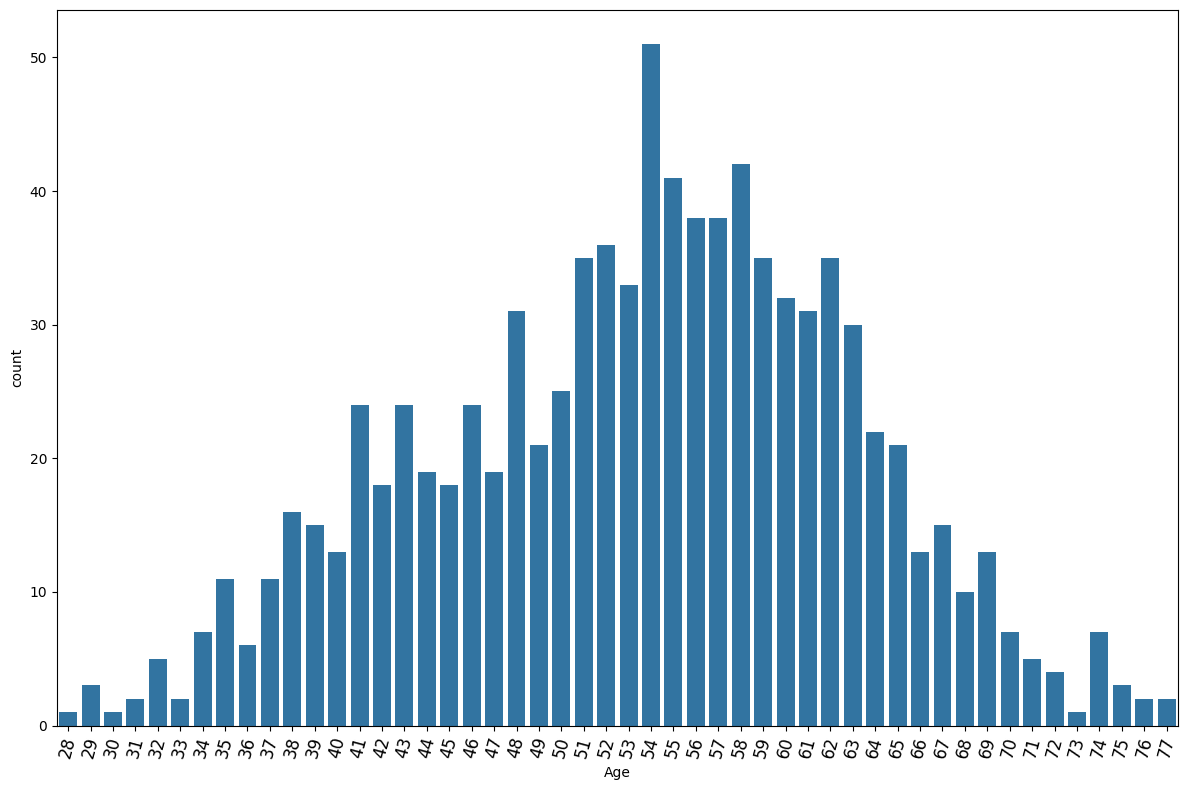

In [ ]:
plt.figure(figsize=[12,8])
p = sns.countplot(data=df, x="Age")
plt.xticks(rotation=75,fontsize=12)  # Rotate x-axis labels to avoid overlap
plt.tight_layout()       # Adjust layout to fit everything
plt.show()

Univariate Plot
we will find that the most patient there age is 54 so it will bs more predicated that the 54 patient has herat disease

In [ ]:
print(df.columns)

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')


In [ ]:
df['HeartDisease']

0      0
1      1
2      0
3      1
4      0
      ..
913    1
914    1
915    1
916    1
917    0
Name: HeartDisease, Length: 918, dtype: int64

In [ ]:
d={0: 'upsloping', 1: 'flat', 2: 'downsloping'}

ST_Slope
1    460
2    395
0     63
Name: count, dtype: int64


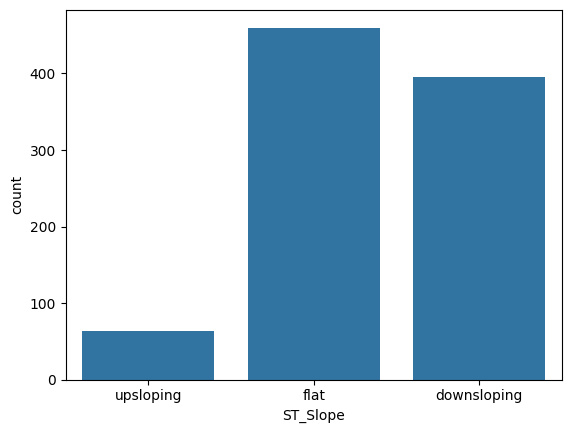

In [ ]:
x=(df.ST_Slope.value_counts())
print(x)
p = sns.countplot(data=df, x="ST_Slope")
plt.xticks(list(d.keys()),list(d.values()))
plt.show()

 [Up: upsloping, Flat: flat, Down: downsloping]
 so the flat are the most in dataset

In [ ]:
x=(df.RestingBP.value_counts())
print(x)

RestingBP
120    132
130    118
140    107
110     58
150     55
      ... 
185      1
98       1
92       1
113      1
164      1
Name: count, Length: 67, dtype: int64


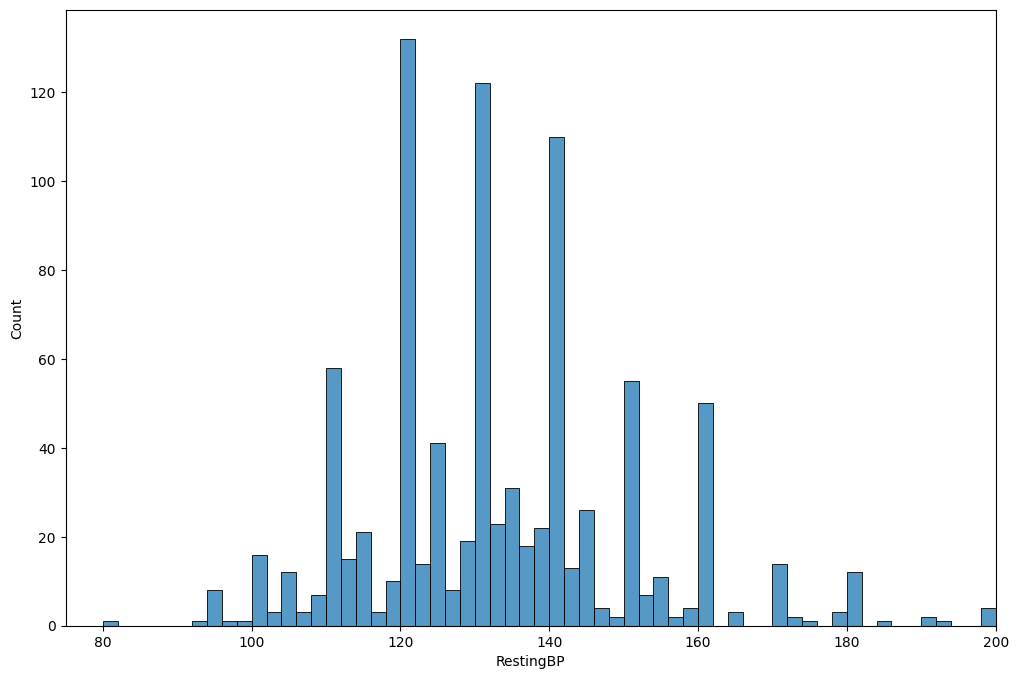

In [ ]:
plt.figure(figsize=[12,8])
#p = sns.countplot(data=df, x="RestingBP",width=1)
sns.histplot(data = df, x = "RestingBP", bins=100)
plt.xticks(rotation = 0)
plt.xlim(75,200)
plt.show()

RestingBP has the most number 120

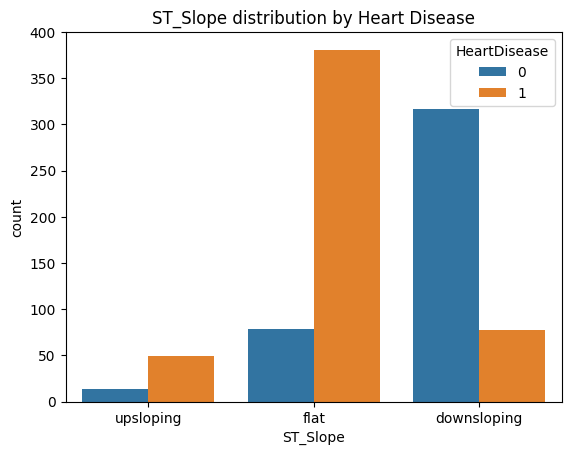

In [ ]:
sns.countplot(data=df, x="ST_Slope", hue="HeartDisease")
plt.title("ST_Slope distribution by Heart Disease")
plt.xticks(list(d.keys()),list(d.values()))
plt.show()


Bivariate which indicates us that 1 which is flat is the most had heart disease

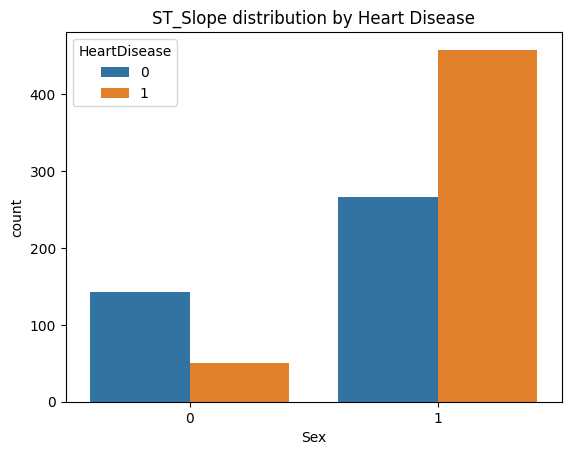

In [ ]:
sns.countplot(data=df, x="Sex", hue="HeartDisease")
plt.title("ST_Slope distribution by Heart Disease")
plt.show()

indicate that most patients are Male

Cholesterol
0      172
85       1
100      2
110      1
113      1
      ... 
491      1
518      1
529      1
564      1
603      1
Name: count, Length: 222, dtype: int64


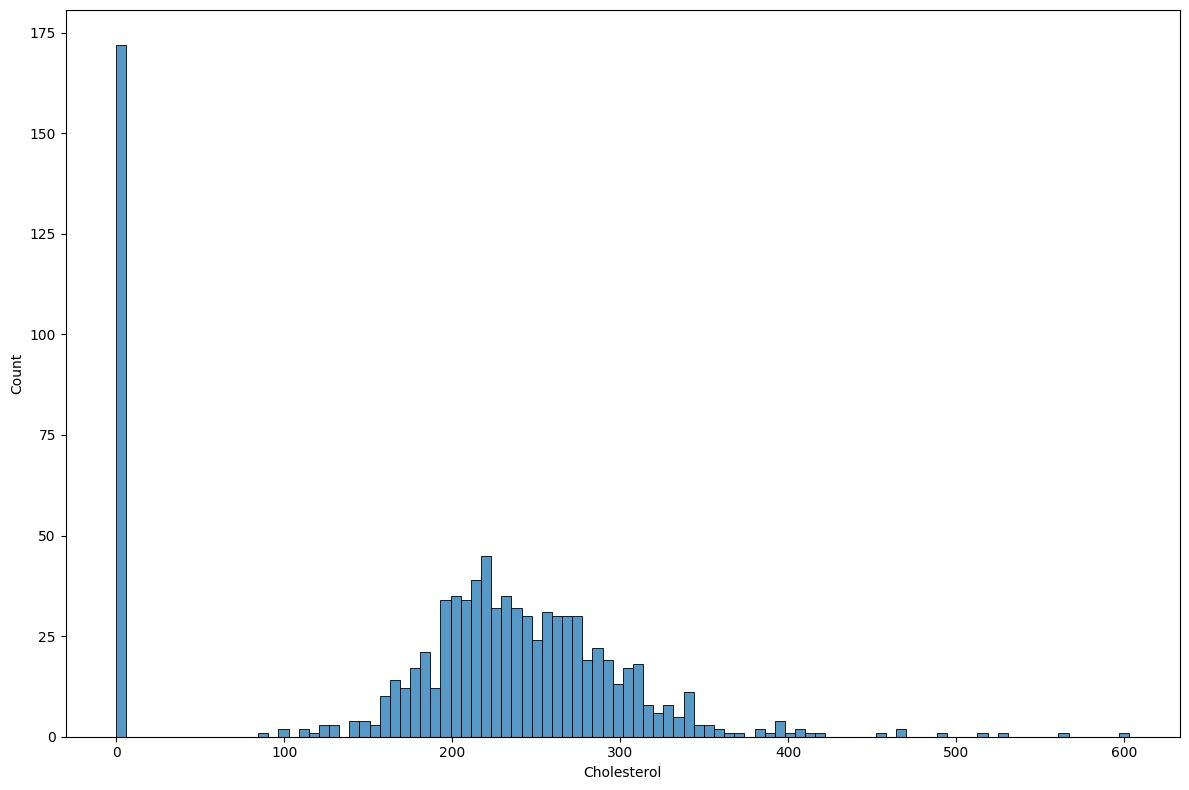

In [ ]:

plt.figure(figsize=[12,8])
x = df['Cholesterol'].value_counts().sort_index()
print(x)

sns.histplot(data = df, x = "Cholesterol",bins=100)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


the most repeated number is 0

FastingBS
0    704
1    214
Name: count, dtype: int64


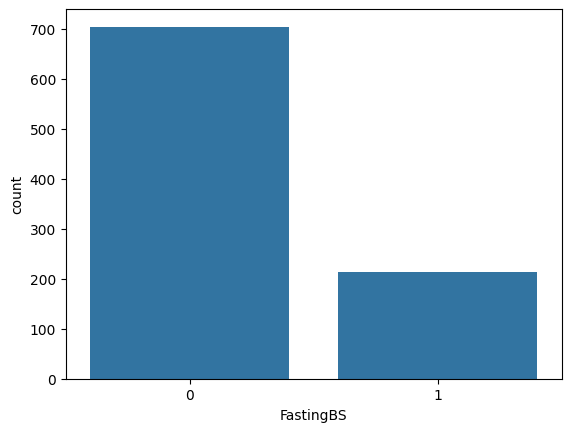

In [ ]:
x=(df.FastingBS.value_counts())
print(x)
p = sns.countplot(data=df, x="FastingBS")
plt.show()

In [ ]:
h={1:'patient',0:'normal'}

HeartDisease
1    508
0    410
Name: count, dtype: int64


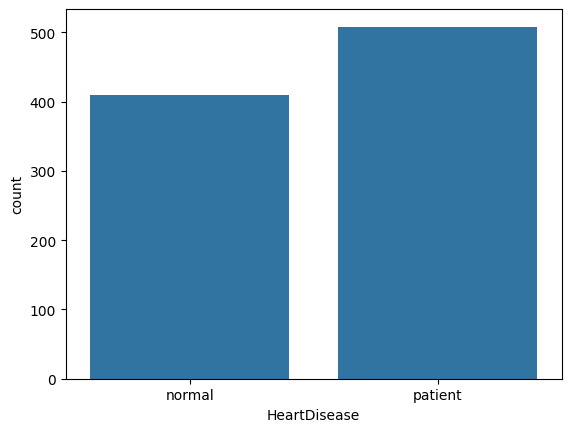

In [ ]:
x=(df.HeartDisease.value_counts())
print(x)
p = sns.countplot(data=df, x="HeartDisease")
plt.xticks(list(h.keys()),list(h.values()))
plt.show()

most of the data has heartdisese


ExerciseAngina
0    547
1    371
Name: count, dtype: int64


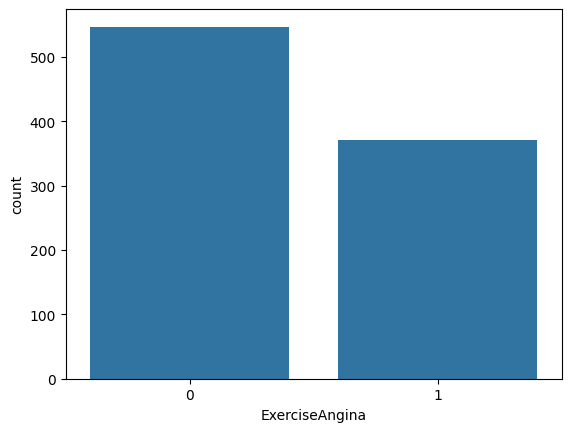

In [ ]:
x=(df.ExerciseAngina.value_counts())
print(x)
p = sns.countplot(data=df, x="ExerciseAngina")
plt.show()

MaxHR
60     1
63     1
67     1
69     1
70     1
      ..
190    2
192    1
194    1
195    1
202    1
Name: count, Length: 119, dtype: int64


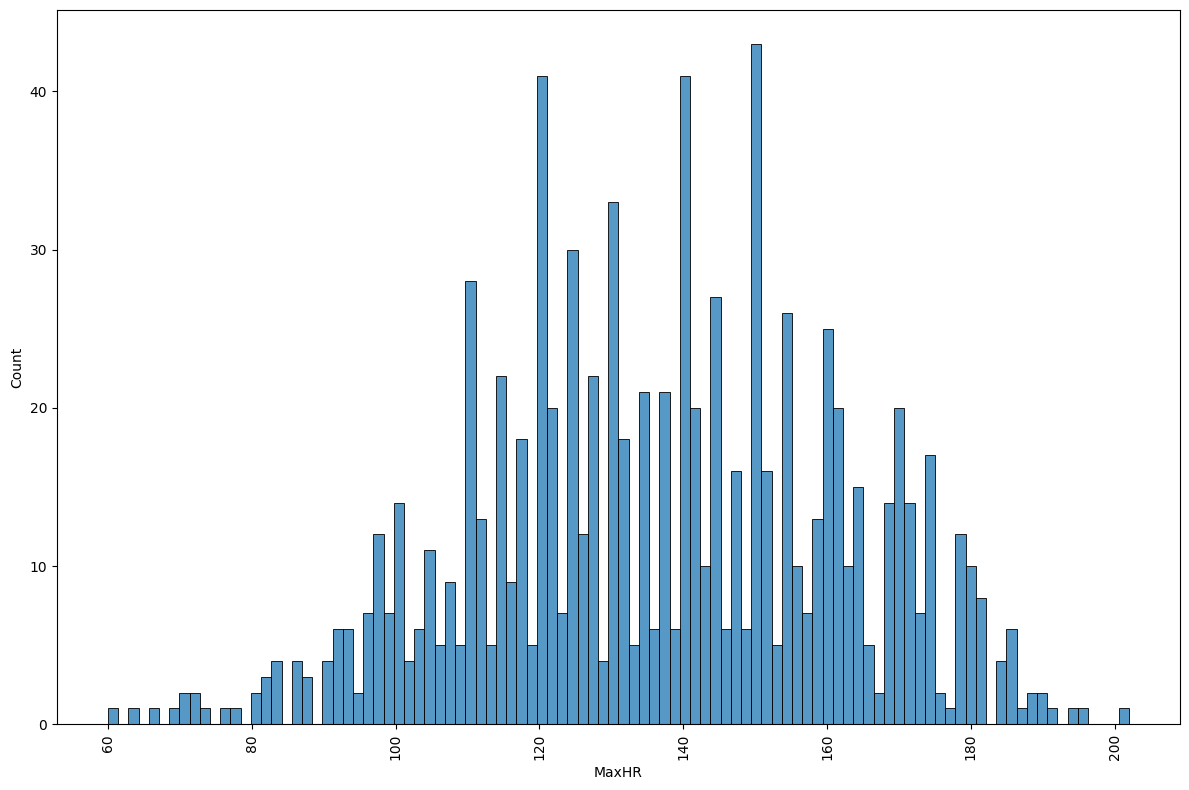

In [ ]:
plt.figure(figsize=[12,8])
x = df['MaxHR'].value_counts().sort_index()
print(x)
sns.histplot(data = df, x = "MaxHR",bins=100)

# Rotate x-axis labels and space them evenly
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

maximum heart rate achieved that is repeated is alraound 142

Oldpeak
-2.6      1
-2.0      1
-1.5      1
-1.1      1
-1.0      2
-0.9      1
-0.8      1
-0.7      1
-0.5      2
-0.1      2
 0.0    368
 0.1     14
 0.2     22
 0.3     11
 0.4     11
 0.5     19
 0.6     14
 0.7      7
 0.8     16
 0.9      4
 1.0     86
 1.1      7
 1.2     26
 1.3      7
 1.4     18
 1.5     53
 1.6     16
 1.7      6
 1.8     17
 1.9      7
 2.0     76
 2.1      2
 2.2      5
 2.3      2
 2.4      4
 2.5     16
 2.6      7
 2.8      7
 2.9      1
 3.0     28
 3.1      1
 3.2      2
 3.4      3
 3.5      2
 3.6      4
 3.7      1
 3.8      1
 4.0      8
 4.2      2
 4.4      1
 5.0      1
 5.6      1
 6.2      1
Name: count, dtype: int64


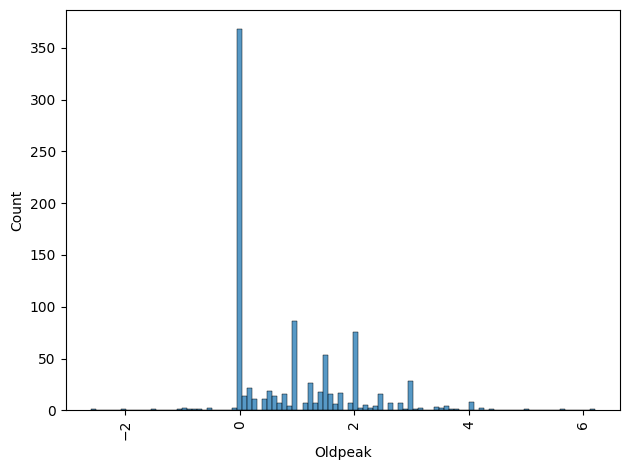

In [ ]:
x = df['Oldpeak'].value_counts().sort_index()
print(x)
sns.histplot(data = df, x = "Oldpeak",bins=100)

# Rotate x-axis labels and space them evenly
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

0 ['normal']is the most

In [ ]:
our_dict = {0: "Typical Angina", 1:"Atypical Angina", 2: "Non-Anginal Pain", 3: "Asymptomatic"}

ChestPainType
0    496
2    203
1    173
3     46
Name: count, dtype: int64


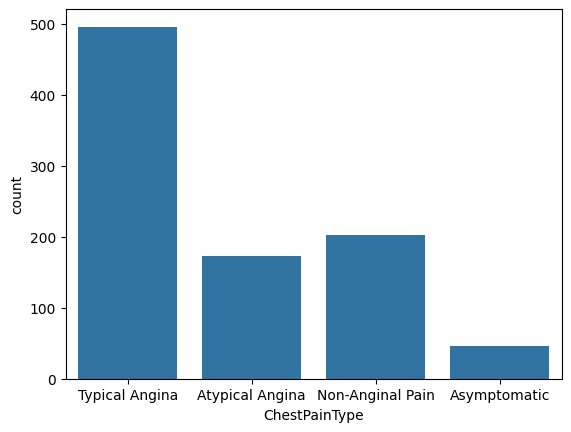

In [ ]:
x=(df.ChestPainType.value_counts())
print(x)
p = sns.countplot(data=df, x="ChestPainType")
plt.xticks(list(our_dict.keys()),list(our_dict.values()))
plt.show()

chest pain type ['0':TA: Typical Angina, '1':ATA: Atypical Angina, '2':NAP: Non-Anginal Pain, '3':ASY: Asymptomatic]
Nap this the most fineded in the data set

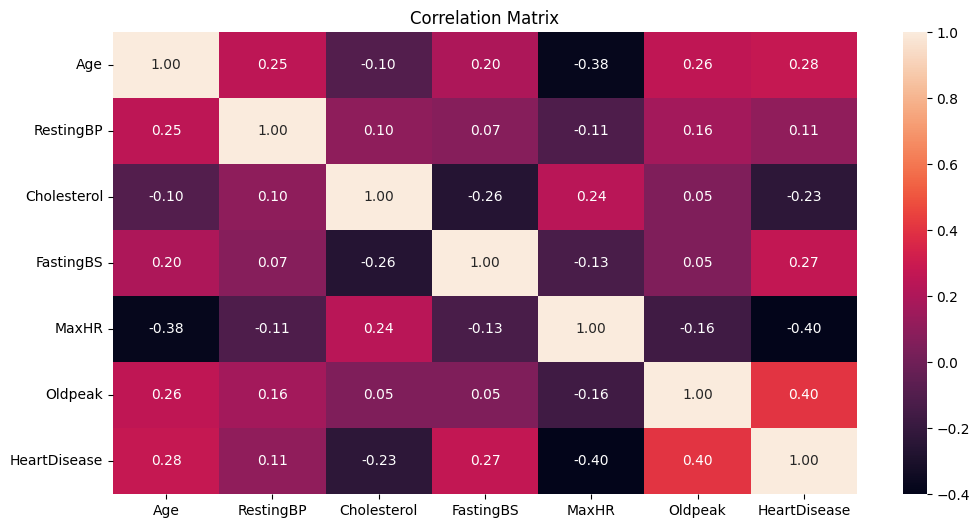

In [ ]:
DF = df.select_dtypes(include=['int64', 'float64'])  # or use number
corr = DF.corr()
plt.figure(figsize=(12, 6))
sns.heatmap(data=corr, annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()



in age highest number is 28 cholestrole has -0.23, max heart rate is -0.40  ,MAXHR= -0.38

In [ ]:

df.groupby('Age')[['HeartDisease']].mean()

,HeartDisease
Age,
28,0.000000
29,0.000000
30,0.000000
31,0.500000
32,0.400000
33,0.500000
34,0.285714
35,0.363636
36,0.333333


In [ ]:
d=df.groupby('HeartDisease')[['Age']].mean()

In [ ]:
d

,Age
HeartDisease,
0,50.551220
1,55.899606


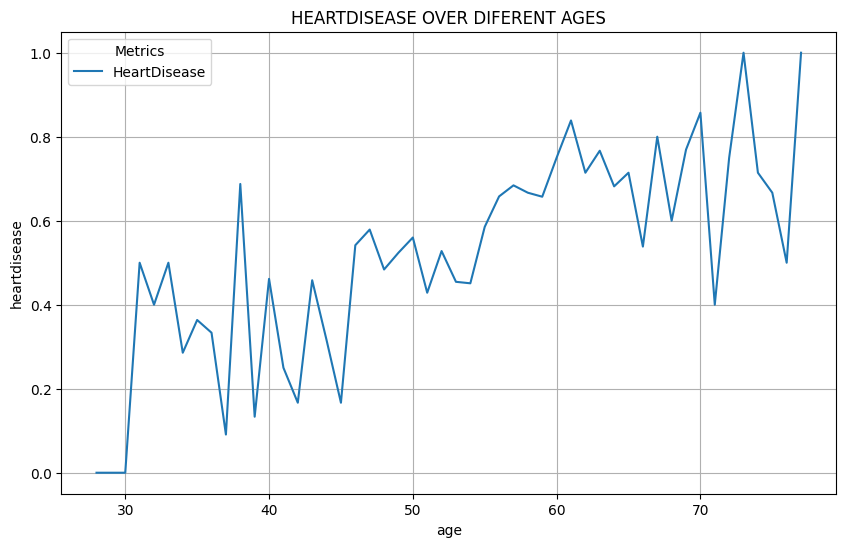

In [ ]:
d=df.groupby('Age')[['HeartDisease']].mean()
# Group the data by date and sum the values for each  ( + index by date)

# Plot all the metrics on the same axes
d.plot(figsize=(10,
                         6)) # plt.plot!
plt.xlabel("age")
plt.ylabel("heartdisease")
plt.title("HEARTDISEASE OVER DIFERENT AGES")
plt.legend(title="Metrics")
plt.grid()
plt.show()

is is going up and down but fromthe half of the 40 is increasing

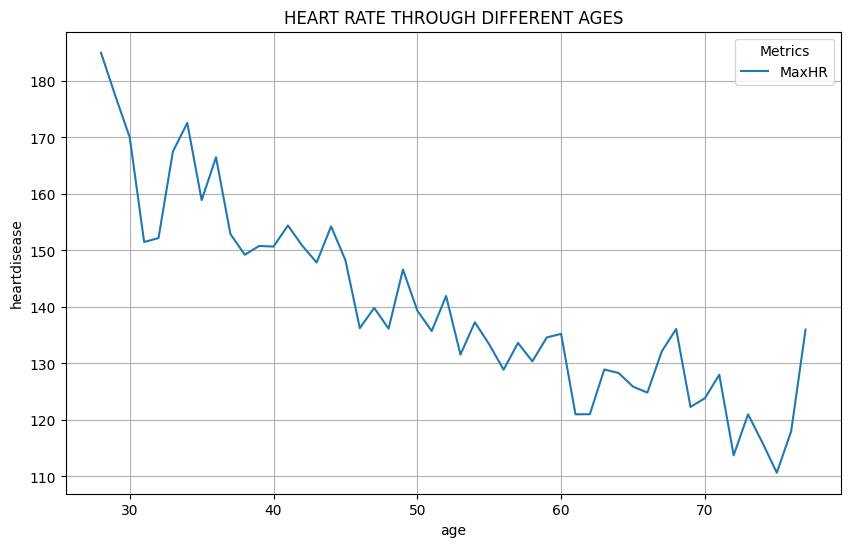

In [ ]:
d=df.groupby('Age')[['MaxHR']].mean()
# Group the data by date and sum the values for each  ( + index by date)

# Plot all the metrics on the same axes
d.plot(figsize=(10,
                         6)) # plt.plot!
plt.xlabel("age")
plt.ylabel("heartdisease")
plt.title("HEART RATE THROUGH DIFFERENT AGES")
plt.legend(title="Metrics")
plt.grid()
plt.show()

In [ ]:
print(df.columns)

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')


# UNIVARIATE

<Figure size 1000x1000 with 0 Axes>

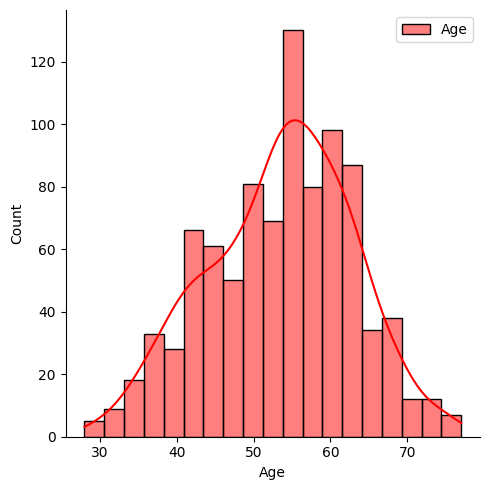

In [ ]:
plt.figure(figsize=(10,10))
sns.displot(df.Age, color="red", label="Age", kde= True)
plt.legend()

<Figure size 1000x1000 with 0 Axes>

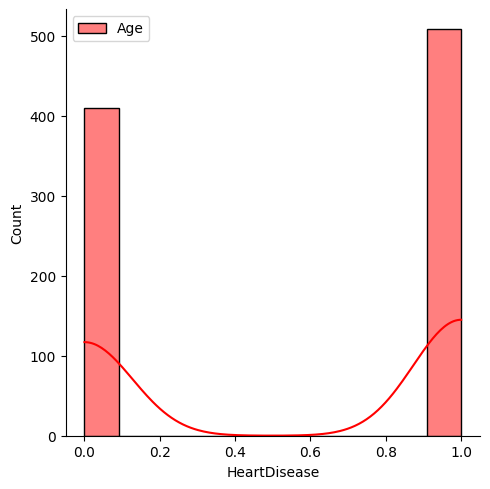

In [ ]:
plt.figure(figsize=(10,10))
sns.displot(df.HeartDisease, color="red", label="Age", kde= True)
plt.legend()

<Figure size 1000x1000 with 0 Axes>

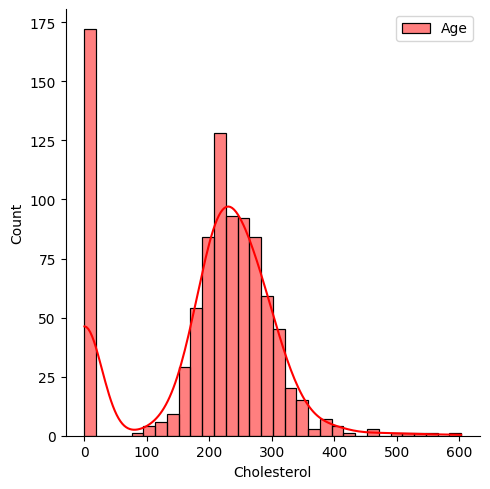

In [ ]:
plt.figure(figsize=(10,10))
sns.displot(df.Cholesterol, color="red", label="Age", kde= True)
plt.legend()

<Figure size 1000x1000 with 0 Axes>

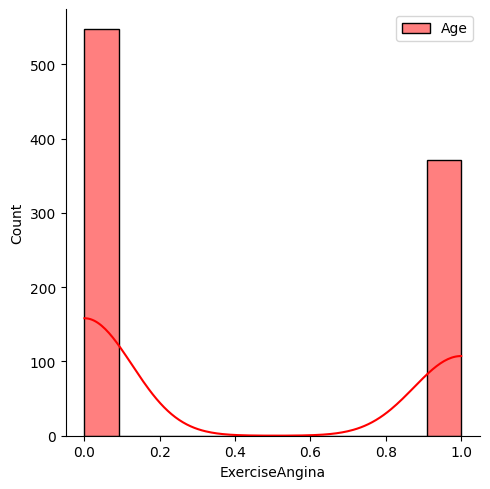

In [ ]:
plt.figure(figsize=(10,10))
sns.displot(df.ExerciseAngina, color="red", label="Age", kde= True)
plt.legend()

<Figure size 1000x1000 with 0 Axes>

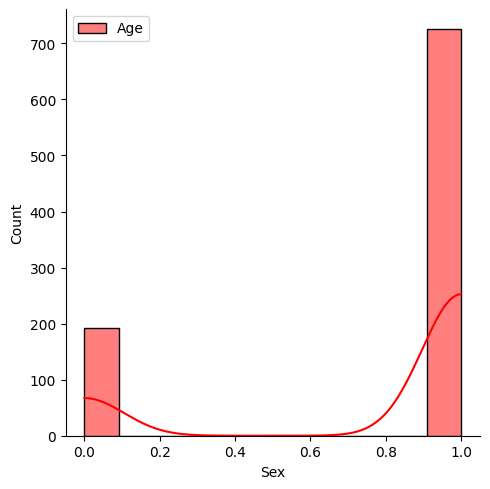

In [ ]:
plt.figure(figsize=(10,10))
sns.displot(df.Sex, color="red", label="Age", kde= True)
plt.legend()

MULTIVARAITE

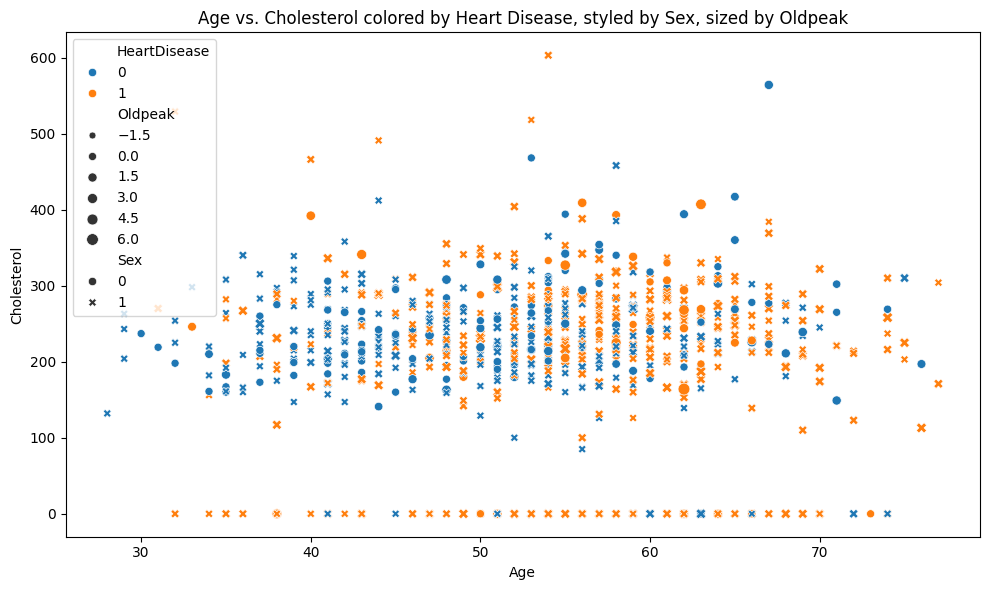

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Cholesterol', hue='HeartDisease', style='Sex', size='Oldpeak')
plt.title('Age vs. Cholesterol colored by Heart Disease, styled by Sex, sized by Oldpeak')
plt.legend()
plt.tight_layout()
plt.show()


# Feature Engineering

In [ ]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

importing library

In [ ]:
from sklearn.preprocessing import StandardScaler as SC
from sklearn.model_selection import train_test_split as TTSPlit
from sklearn.preprocessing import  StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

In [ ]:
X = df[['Cholesterol','Sex','Age','ExerciseAngina']]
y = df['HeartDisease']

we choose which input we are using here i used Cholesterol','Sex','Age','ExerciseAngina', as they are the most affecting or  we can more predict using those inputs and these based on the data visulaiztion especially correlation matrix

In [ ]:
numeric_features = X.select_dtypes(include=['float', 'int']).columns.tolist()
# Preprocessor for scaling numeric features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)] )

here we are Normalizing the dataset (z_score):standardizes the numeric columns (mean = 0, std = 1), and we scale the valuse so correlation matrix == covarinace matrix(PCA), ensuring equal scale values in all columns , make the model fast is important step for the CV AND SVM AND PCA

In [ ]:
#spliting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=40)

In [ ]:
pipeline = Pipeline(steps=[('preprocessor', preprocessor)]) # Create the full pipeline with preprocessing

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Cholesterol', 'Sex', 'Age',
                                                   'ExerciseAngina'])]))])

pipline in scikit-learn is tool helpingin preprocessing and modeling it work by chaining multiplesteps into single object

# SUPPORT VECTOR MACHINE

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

a straight line (or hyperplane)  MARGIN CLASIFIER , TRIES TO FIND BEST HYPERPLANE that separates 2 classes with maximum MARGIN

In [ ]:
y_pred_svm = svm_model.predict(X_test)

In [ ]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)  # Calculate accuracy
report_svm = classification_report(y_test, y_pred_svm)  # Generate a classification report
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)

In [ ]:
print(f"SVM Accuracy: {accuracy_svm * 100:.2f}%")
print("\nSVM Classification Report:")
print(report_svm)
print("\nSVM Confusion Matrix:")
print(conf_matrix_svm)

SVM Accuracy: 82.61%

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.87      0.80        75
           1       0.90      0.80      0.84       109

    accuracy                           0.83       184
   macro avg       0.82      0.83      0.82       184
weighted avg       0.84      0.83      0.83       184


SVM Confusion Matrix:
[[65 10]
 [22 87]]


SO OUR ACCURACY HERE USING SUPPORT VECTOR MACHINE IS  82.61%


# PCA(Principal Component Analysis)

is dimensionaltity reduction it work through reducing the number of feature in the dataset which has the most information by choosing the best lamda

In [ ]:
from sklearn.decomposition import PCA,KernelPCA
DR_3d = PCA(n_components=3) # 3D > Linear
DR_2d = PCA(n_components=2) # 2D > Linear
DR_2d_Components = DR_2d.fit_transform(X_train)

In [ ]:
DR_2d_Components_DF = pd.DataFrame(DR_2d_Components,columns=['PC1','PC2'])

In [ ]:
np.sort(y_train.value_counts().index)

array([0, 1], dtype=int64)

Text(0, 0.5, 'PC2')

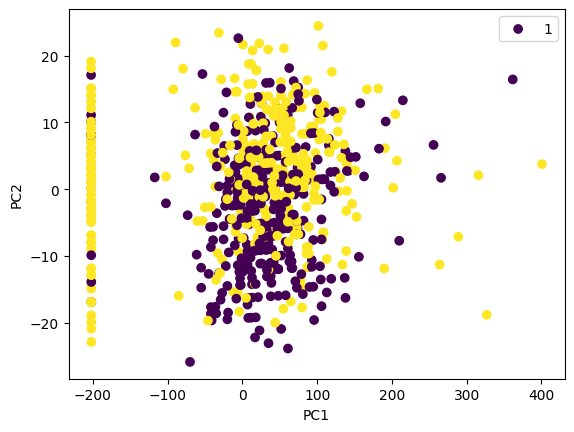

In [ ]:
import matplotlib.pyplot as plt, seaborn as sb
plt.scatter(DR_2d_Components_DF['PC1'],
            DR_2d_Components_DF['PC2'],
            c=y_train)
plt.legend(np.array(y_train.value_counts().index)) # Need to have all legends
plt.xlabel("PC1")
plt.ylabel("PC2")

this plots means that the pca is not good chooce for this data as it overlaps


# regularization
# Elastic Net

Elastic Net is a hybrid regularization technique that combines the penalties of L1 and L2 regularization:

$$ \text{Penalty}_{\text{ElasticNet}} = \rho \sum_{i=1}^{n} |w_i| + (1 - \rho) \sum_{i=1}^{n} w_i^2 $$

Here, $\rho$ is the mixing parameter that controls the balance between L1 and L2 regularization penalties. Elastic Net is particularly useful when there are multiple features correlated with each other. It combines the feature selection capability of L1 with the regularization strength of L2, making it a versatile choice for various modeling

In [ ]:
from sklearn.linear_model import ElasticNetCV

In [ ]:
n = X_train.shape[0]

In [ ]:
lambda_max = np.abs(X_train.T.dot(y_train)).max()/n
lambdas = np.logspace( # Points dividable by lambda_max
    np.log10(lambda_max * 10),
    np.log10(lambda_max * 0.1),
    100
)
l1_ratio = [.9]

In [ ]:
ENCV = ElasticNetCV(alphas=lambdas,
                    l1_ratio = l1_ratio,
                    cv = 5)
ENCV.fit(X_train,y_train)

ElasticNetCV(alphas=array([982.22070845, 937.57726135, 894.96292782, 854.28548152,
       815.45688794, 778.39311385, 743.0139455 , 709.24281496,
       677.00663442, 646.23563803, 616.86323093, 588.82584505,
       562.06280164, 536.51617985, 512.13069145, 488.85356113,
       466.63441231, 445.4251581 , 425.17989722, 405.8548147 ,
       387.408087  , 369.79979154, 352.99182029, 336.94779727,
       321.63299986, 307...
        34.48765233,  32.9201353 ,  31.42386435,  29.99560121,
        28.63225485,  27.33087467,  26.08864424,  24.90287509,
        23.77100099,  22.69057231,  21.65925078,  20.6748044 ,
        19.73510263,  18.83811176,  17.98189051,  17.16458583,
        16.38442891,  15.63973133,  14.92888141,  14.25034071,
        13.60264073,  12.98437971,  12.39421962,  11.83088321,
        11.29315131,  10.77986015,  10.28989887,   9.82220708]),
             cv=5, l1_ratio=[0.9])

In [ ]:
ENCV.coef_
coef = pd.Series(ENCV.coef_, index=pd.DataFrame(X_train,columns=X_train.columns).columns)

In [ ]:
coef

Cholesterol      -0.000243
Sex               0.000000
Age               0.000000
ExerciseAngina    0.000000
dtype: float64

In [ ]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model  import LogisticRegressionCV
from sklearn.metrics       import accuracy_score, roc_auc_score

# Encode target
y_cls = y_train

# Scale input
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# Compute lambda_max
n = X_scaled.shape[0]
lambda_max = np.abs(X_scaled.T.dot(y_cls)).max() / n

# Create Cs grid
Cs = np.logspace(
    np.log10(1e-6 / lambda_max),
    np.log10(1e-5 / lambda_max),
    30
)

# Fit ElasticNet Logistic Regression with CV
logcv = LogisticRegressionCV(
    Cs         = Cs,
    penalty    = 'elasticnet',
    solver     = 'saga',
    l1_ratios  = [0.9],
    cv         = 3,
    scoring    = 'neg_log_loss',
    max_iter   = 1000,
    n_jobs     = -1,
    refit      = True
)
logcv.fit(X_scaled, y_cls)

# Evaluate
preds = logcv.predict(X_scaled)
acc   = accuracy_score(y_cls, preds)

print(f"Best l1_ratio (ρ):   {logcv.l1_ratio_[0]:.2f}")
print(f"Best C (1/λ):        {logcv.C_[0]:.6e}")
print(f"Train accuracy:      {acc:.4f}")

coefs = pd.Series(logcv.coef_.ravel(), index=X_train.columns)
print(f"Kept { (coefs!=0).sum() } features, dropped { (coefs==0).sum() }")
print(coefs.sort_values())


Best l1_ratio (ρ):   0.90
Best C (1/λ):        5.138895e-06
Train accuracy:      0.5436
Kept 0 features, dropped 4
Cholesterol       0.0
Sex               0.0
Age               0.0
ExerciseAngina    0.0
dtype: float64


that the input needs to change .. y is predidactable

# RANDOMFOREST

IT BULID"FOREST" OF DECISION TRESS AND COMBINE THEM TO MAKE BEAT DECISION BUT LESS OVERFITTING

WE HAVE applied 5-fold cross-validation using a Random Forest Classifier.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
from sklearn.model_selection import cross_val_score
cross_val_score(model, X_train, y_train, cv=5)

array([0.72789116, 0.70748299, 0.73469388, 0.7414966 , 0.7260274 ])

HERE IT INDICATE THE ACCUTACY OF EACH FOLD

In [ ]:
model.fit(X_train,y_train)

RandomForestClassifier()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy_score(y_test, y_pred)

0.7554347826086957

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.69      0.70        75
           1       0.79      0.80      0.79       109

    accuracy                           0.76       184
   macro avg       0.75      0.75      0.75       184
weighted avg       0.75      0.76      0.76       184



ACCURACY IS 75.5%

<Axes: >

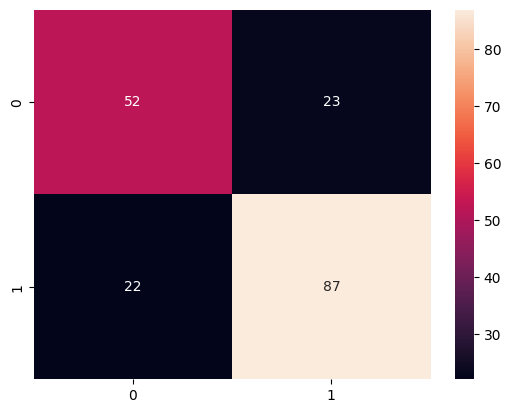

In [ ]:
sb.heatmap(confusion_matrix(y_test, y_pred),annot=True)

52 TP

23 FP

22 FN

87 TN

# BEST MODEL

Precision = TP / (TP + FP) = 87 / (87+23)

Recall = TP / (TP + FN) = 87 / (87+22)

F1-score = harmonic mean of precision & recall

![alt text](image.png)

![alt text](image-1.png)

FROM THE 2 PHOTOS WE WILL  FIND OUT THAT THE DIFFERNEC IN THE PRECISION AND RECALL IS SMALL DIFFERENCE IN NUMBERS BUT IN THE SVM(82%) THE ACCURACY IS MORE THAN THE RANDOM FOREST(72%) WHICH MAKE THE SVM BETTER FOR THIS MODEL

![alt text](image-2.png)

THIS PHOTO MAKES THE SVM IS BEST AS PCA OVERLAPS AND WE CANT USING FOR PREDICTION THIS MODEL SO  
# SVM IS THE BEST FOR THIS MODEL

#  GridSearch CV
In practice, decision trees can **overfit**, so you regularize them with parameters like:
- `max_depth`
- `min_samples_split`
- `min_samples_leaf`

FIND THE BEST HYPERPARAMETERS FOR THE MODEL

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier




In [ ]:
model = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}


In [ ]:
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,                # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy', verbose=1)

In [ ]:
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,                # 5-fold cross-validation
    scoring='accuracy',  # or 'roc_auc', 'f1', etc.
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy', verbose=1)

In [ ]:
print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)
best_model = grid_search.best_estimator_


Best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best score: 0.7779051346566024


In [ ]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# SVM works better with scaled data
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])

param_grid_svm = {
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma': ['scale', 'auto']  # Only used for RBF kernel
}

grid_svm = GridSearchCV(
    estimator=pipe_svm,
    param_grid=param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X_train, y_train)

print("SVM - Best Parameters:", grid_svm.best_params_)
print("SVM - Best Score:", grid_svm.best_score_)


Fitting 5 folds for each of 12 candidates, totalling 60 fits
SVM - Best Parameters: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
SVM - Best Score: 0.7956667598546268


HERE WE FOUND OUT THAT THE SVM IS ALSO THE BEST BUT THE DIFFERNEC IS QUIET SMALL